<a href="https://colab.research.google.com/github/derekmok/machine-vision-coursework/blob/main/Machine_Vision_Final_Lab_Model_Training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!git init .
!git remote add origin https://github.com/derekmok/machine-vision-coursework.git
!git pull origin main

!pip install -r requirements.txt

## Download the data

The data for this assignment has been made available and is downloadable to disk by running the below cell.

import os

In [ ]:
import boto3
from botocore import UNSIGNED
from botocore.config import Config

# Connect to S3 without authentication (public bucket)
s3 = boto3.client('s3', config=Config(signature_version=UNSIGNED))

bucket_name = 'prism-mvta'
prefix = 'training-and-validation-data/'
download_dir = './video-data'

os.makedirs(download_dir, exist_ok=True)

# List all objects in the S3 path
paginator = s3.get_paginator('list_objects_v2')
pages = paginator.paginate(Bucket=bucket_name, Prefix=prefix)

video_names = []

for page in pages:
    if 'Contents' not in page:
        print("No files found at the specified path! Go and complain to the TAs!")
        break

    for obj in page['Contents']:
        key = obj['Key']
        filename = os.path.basename(key)

        if not filename:
            continue

        video_names.append(filename)

        local_path = os.path.join(download_dir, filename)
        print(f"Downloading: {filename}")
        s3.download_file(bucket_name, key, local_path)

print("\n" + "="*50)
print("Downloaded videos:")
print("="*50)
for name in video_names:
    print(name)

print(f"\nTotal: {len(video_names)} files")

These videos are now available in the folder "video-data". You can click on the folder icon on the left-hand-side of this screen to see the videos in a file explorer.

# Create your Datasets and Dataloaders

Some example code for approaching the first *two* TODOs is given below just to get you started. No starter code is given for the third TODO.

Note, the below code is very rough skeleton code. Make no assumptions as to the correct manner to architect your model based on the structure of this code.

Please feel free to (if not encouraged to) change every single line of the below code (change it to best suit your chosen model architecture, in the next section).

### TODO 1 (This is mostly already done for you - Please see the v1 provided below)

Each video in the folder is prefixed by a number. That number corresponds to the number of distinct pushups visible in the video. Write code to iterate over each video in the folder, and extract the corresponding target associated with the video.

### TODO 2 (This is also mostly already done for you - Please see the v1 provided below)


Divide the data into training and validation sets.

Optionally, you can also create out your own test set to assess your performance.

### TODO 3

Any preprocessing or augmentation of your data which you deem required, should (probably) go here. You are also free to include your data-augmentation code later, though doing it before creating your dataloaders is probably a good idea.

If you complete this TODO, to maintain experimental hygiene, feel free to modify the code which was provided for TODOs 1 and 2.

In [1]:
# Here is a basic implementation of the above two TODOs. You can assume the first TODO is completed correctly.

# Please modify this code to suit you best, as you decide on your preferred model architecture.

# For example, below here we are padding every video to 1,000 frames. That may or may not be a good idea.

from data_loader import VideoDataset

# Create a Model

For this assignment, we request you use PyTorch. Below is an example of how to instantiate a very basic PyTorch model.

Note, this model below needs a _lot_ of work.

Please include your code for creating your model below.

The only constraint here is that you define a Python object which inherits from a PyTorch nn.Module object. Beyond that, please feel free to implement anything you like: Transformer, Vision Transformer, MLP, CNN, etc.

### TODO 4

Create your model.

In [2]:
import torch
from neural_net.temporal_conv_net import TCNPushUpCounter

# Train your Model

### TODO 5

Training time! Please include your training code below.

As per above, please feel free (and encouraged) to rip out all of the below code and replace with your (much better) code.

The below should just be used as an example to get you started.

In [3]:
import torch.optim as optim
from neural_net.ensemble_trainer import EnsembleTrainer
from feature_engineering.transforms import Compose, RandomScaling, RandomNoise, RandomTimeWarp, RandomSequenceReverse, \
    RandomSequenceRepeat, RandomHorizontalFlipLandmarks, RandomDropout
from neural_net.kl_divergence_loss import KLDivergenceDensityLoss


def train_model():
    trainer = EnsembleTrainer(
        model_factory=lambda: TCNPushUpCounter(),
        loss_fn=KLDivergenceDensityLoss(lambda_count=1e-1),
        optimizer_factory=lambda parameters : optim.AdamW(parameters),
        patience=100,
        max_epochs=1000
    )

    return trainer.train(
        dataset=VideoDataset("video-data"),
        train_transform=Compose([
            RandomSequenceRepeat(),
            RandomSequenceReverse(),
            RandomHorizontalFlipLandmarks(),
            RandomTimeWarp(p=0.8),
            RandomScaling(),
            RandomNoise(p=1.0),
            RandomDropout()
        ])
    )

In [4]:
# setting a manual seed for reproducibility
!mkdir -p .models && wget --no-clobber -O .models/pose_landmarker.task https://storage.googleapis.com/mediapipe-models/pose_landmarker/pose_landmarker_heavy/float16/1/pose_landmarker_heavy.task
torch.manual_seed(42)
training_results = train_model()

File ‘.models/pose_landmarker.task’ already there; not retrieving.


Training Folds:   0%|          | 0/5 [00:00<?, ?fold/s]

Fold 1/5:   0%|          | 0/1000 [00:00<?, ?epoch/s]

  Fold 1 complete in 1m 31s | Best epoch: 615 | Val Loss: 0.3490, MAE: 0.23, Exact: 87.5%, Off1: 100.0%


Fold 2/5:   0%|          | 0/1000 [00:00<?, ?epoch/s]

...

  Fold 3 complete in 1m 36s | Best epoch: 635 | Val Loss: 0.5435, MAE: 0.21, Exact: 100.0%, Off1: 100.0%


Fold 4/5:   0%|          | 0/1000 [00:00<?, ?epoch/s]

  Fold 4 complete in 1m 18s | Best epoch: 462 | Val Loss: 0.2154, MAE: 0.17, Exact: 86.7%, Off1: 100.0%


Fold 5/5:   0%|          | 0/1000 [00:00<?, ?epoch/s]

  Fold 5 complete in 36.7s | Best epoch: 162 | Val Loss: 0.4998, MAE: 0.32, Exact: 73.3%, Off1: 100.0%

Training Complete!
Total time: 5m 37s
Average time per fold: 1m 7s


# Evaluation

## TODO 6

Include any code which you feel is useful for evaluating your model performance below.

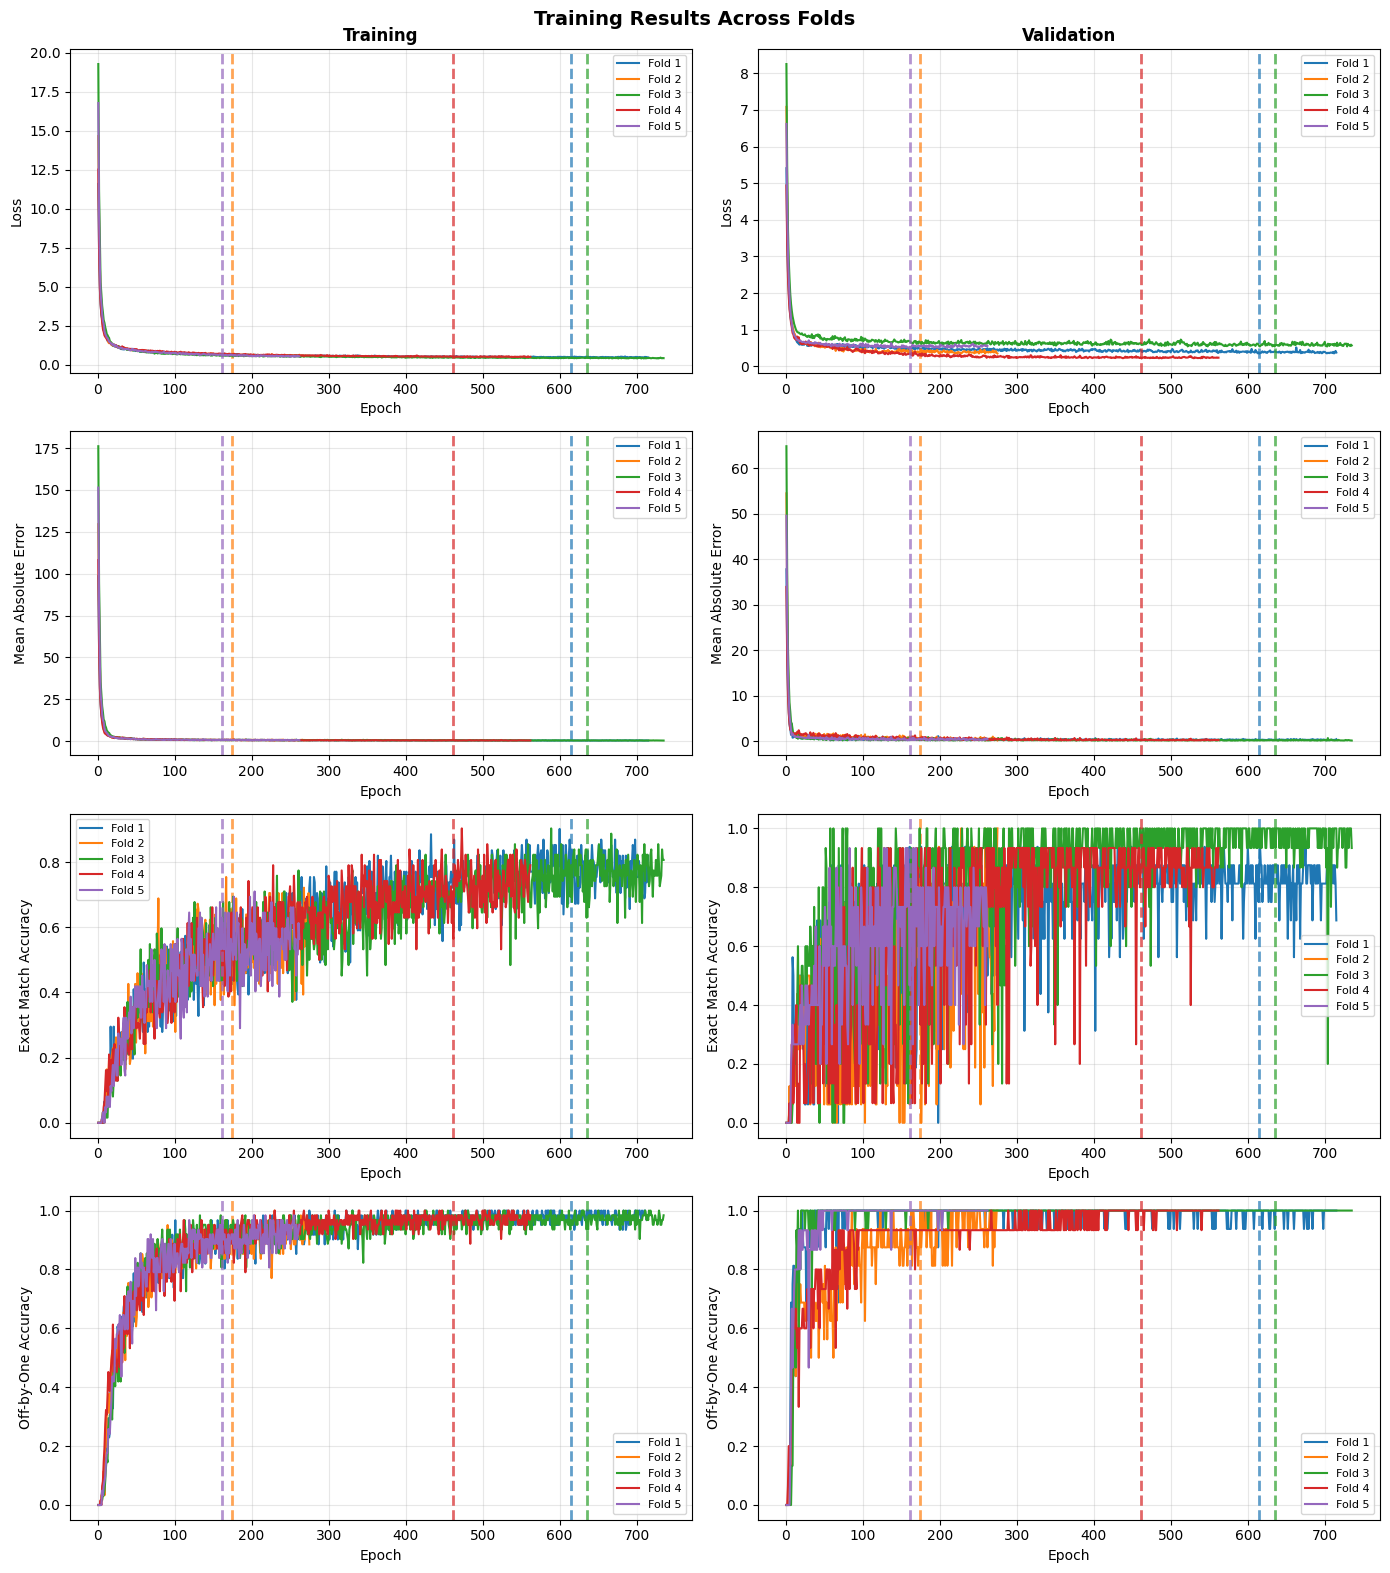

Training results saved to 'training_results.png'


In [5]:
import matplotlib.pyplot as plt


def plot_training_results(results):
    """Plot training and validation metrics for all folds.
    
    Creates a 4x2 grid showing training (left) and validation (right) for:
    - Loss
    - Mean Absolute Error
    - Exact Match Accuracy
    - Off-by-One Accuracy
    
    Args:
        results: EnsembleResult object from training
    """
    fig, axes = plt.subplots(4, 2, figsize=(14, 16))
    fig.suptitle('Training Results Across Folds', fontsize=14, fontweight='bold')

    # Column headers
    axes[0, 0].set_title('Training', fontsize=12, fontweight='bold')
    axes[0, 1].set_title('Validation', fontsize=12, fontweight='bold')

    metrics = [
        ('loss', 'Loss', 0),
        ('mean_absolute_error', 'Mean Absolute Error', 1),
        ('exact_match_accuracy', 'Exact Match Accuracy', 2),
        ('off_by_one_accuracy', 'Off-by-One Accuracy', 3),
    ]

    colors = plt.cm.tab10.colors

    for metric_name, metric_label, row_idx in metrics:
        train_ax = axes[row_idx, 0]
        val_ax = axes[row_idx, 1]

        for fold_result in results.fold_results:
            fold_idx = fold_result.fold_index
            color = colors[fold_idx % len(colors)]

            # Extract metric values from history
            train_values = [getattr(m, metric_name) for m in fold_result.train_history]
            val_values = [getattr(m, metric_name) for m in fold_result.val_history]
            epochs = range(1, len(train_values) + 1)

            # Plot training metrics (left column)
            train_ax.plot(epochs, train_values, '-', color=color,
                          label=f'Fold {fold_idx + 1}')
            train_ax.axvline(x=fold_result.best_epoch + 1, color=color,
                             linestyle='--', linewidth=2, alpha=0.7)

            # Plot validation metrics (right column)
            val_ax.plot(epochs, val_values, '-', color=color,
                        label=f'Fold {fold_idx + 1}')
            val_ax.axvline(x=fold_result.best_epoch + 1, color=color,
                           linestyle='--', linewidth=2, alpha=0.7)

        # Configure training axis
        train_ax.set_xlabel('Epoch')
        train_ax.set_ylabel(metric_label)
        train_ax.grid(True, alpha=0.3)
        train_ax.legend(fontsize=8, loc='best')

        # Configure validation axis
        val_ax.set_xlabel('Epoch')
        val_ax.set_ylabel(metric_label)
        val_ax.grid(True, alpha=0.3)
        val_ax.legend(fontsize=8, loc='best')

    plt.tight_layout()
    plt.savefig('training_results.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Training results saved to 'training_results.png'")


# Plot the training results
plot_training_results(training_results)

## Ensemble Evaluation

Evaluate the ensemble model on the full training dataset.

Created ensemble with 5 models

Ensemble Evaluation Results on Training Set
Mean Absolute Error:     0.1469
Exact Match Accuracy:    94.81%
Off-by-One Accuracy:     100.00%


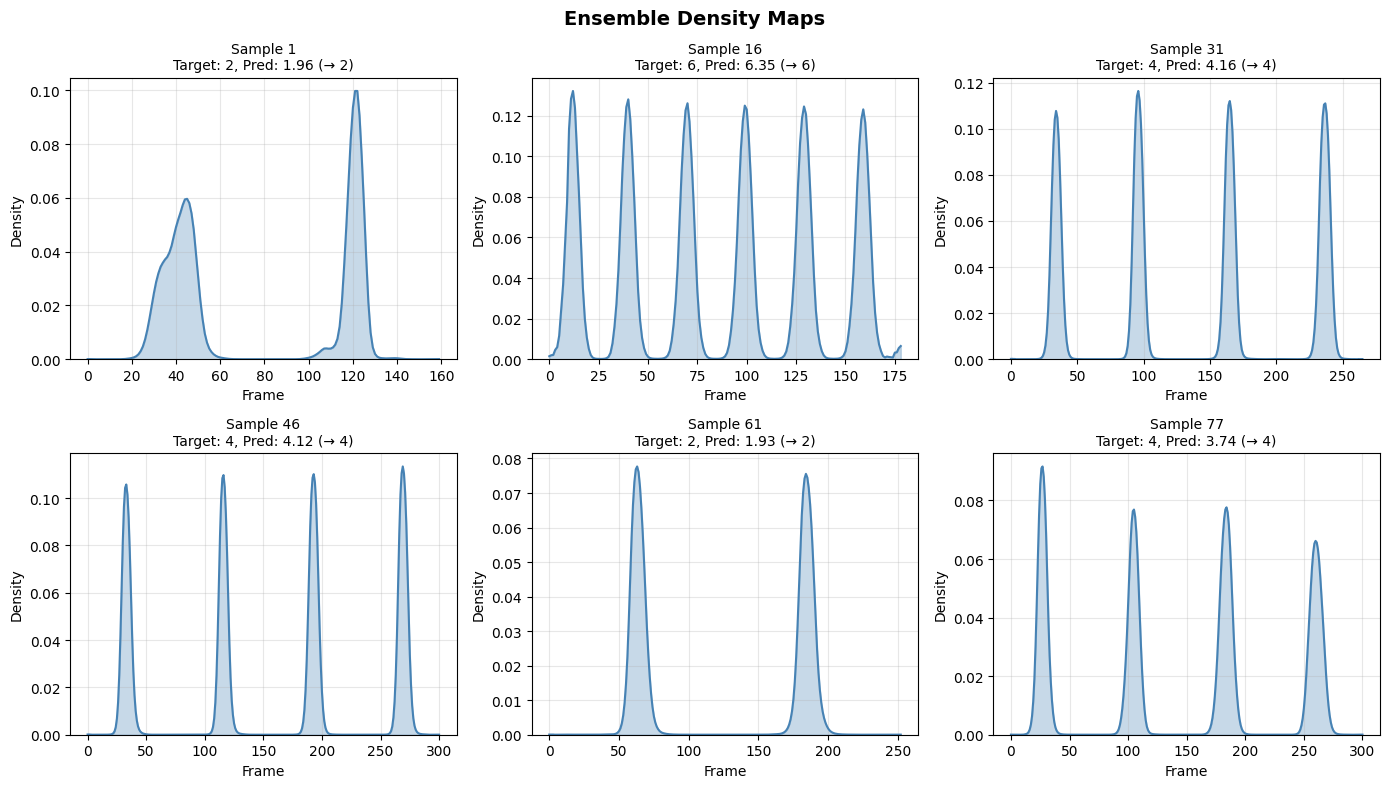

Density maps saved to 'ensemble_density_maps.png'


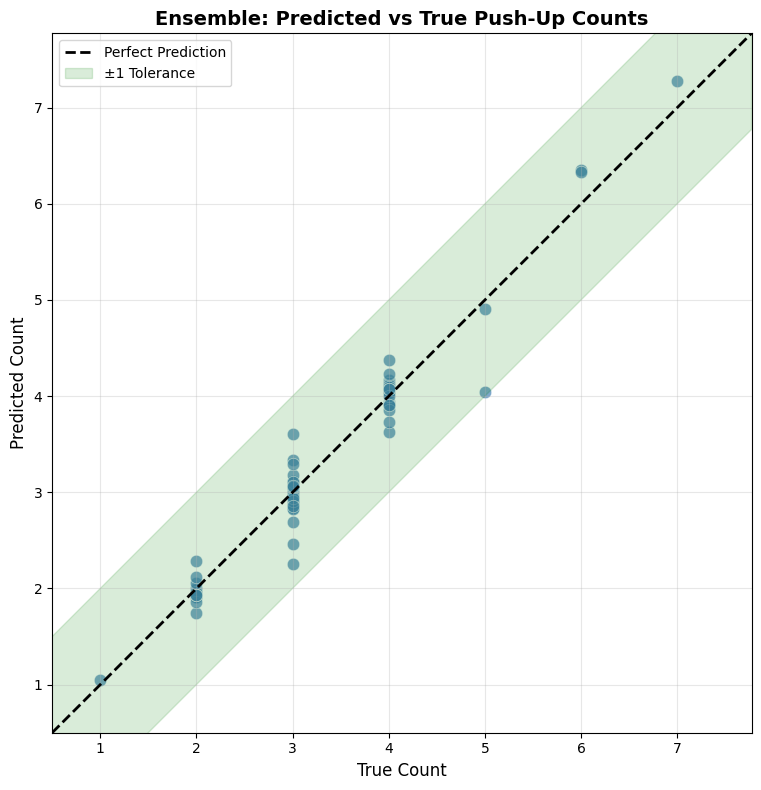

Plot saved to 'predicted_vs_true.png'


In [6]:
from neural_net.ensemble_wrapper import EnsembleWrapper
from torch.utils.data import DataLoader
import numpy as np

def create_ensemble_from_results(training_results, input_channels=6):
    """Create an EnsembleWrapper and load weights from training results.
    
    Args:
        training_results: EnsembleResult from training
        input_channels: Number of input channels for TCNPushUpCounter
        
    Returns:
        EnsembleWrapper with loaded weights
    """
    # Create 5 fresh TCNPushUpCounter instances
    models = [TCNPushUpCounter(input_channels=input_channels) for _ in range(len(training_results.fold_results))]

    # Extract state dicts from training results
    state_dicts = [fold.model_state_dict for fold in training_results.fold_results]

    # Use the static factory method to create and hydrate the ensemble
    ensemble = EnsembleWrapper.from_pretrained_models(models, state_dicts)

    return ensemble


def evaluate_ensemble_on_dataset(ensemble, dataset, device=None):
    """Evaluate ensemble on a dataset and compute statistics.
    
    Args:
        ensemble: EnsembleWrapper model
        dataset: Dataset to evaluate on
        device: torch.device (defaults to cuda if available)
        
    Returns:
        Dictionary with predictions, targets, and metrics
    """
    if device is None:
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    ensemble = ensemble.to(device)
    ensemble.eval()

    all_predictions = []
    all_targets = []
    all_density_maps = []

    loader = DataLoader(dataset, batch_size=1, shuffle=False)

    with torch.no_grad():
        for sequences, density_maps, labels, _ in loader:
            sequences = sequences.to(device)

            # Get ensemble predictions
            predictions, density_maps = ensemble(sequences)

            all_predictions.append(predictions.cpu().squeeze().item())
            all_targets.append(labels.item())
            all_density_maps.append(density_maps.cpu().squeeze().numpy())

    predictions = np.array(all_predictions)
    targets = np.array(all_targets)
    rounded_preds = np.round(predictions)

    # Compute metrics
    mae = np.mean(np.abs(predictions - targets))
    exact_match = np.mean(rounded_preds == targets)
    off_by_one = np.mean(np.abs(rounded_preds - targets) <= 1)

    return {
        'predictions': predictions,
        'rounded_predictions': rounded_preds,
        'targets': targets,
        'density_maps': all_density_maps,
        'mae': mae,
        'exact_match_accuracy': exact_match,
        'off_by_one_accuracy': off_by_one,
    }


def plot_density_maps(results, num_samples=6):
    """Plot density maps for a handful of samples.
    
    Args:
        results: Dictionary from evaluate_ensemble_on_dataset
        num_samples: Number of samples to plot
    """
    indices = np.linspace(0, len(results['density_maps']) - 1, num_samples, dtype=int)

    fig, axes = plt.subplots(2, 3, figsize=(14, 8))
    axes = axes.flatten()

    for i, idx in enumerate(indices):
        density_map = results['density_maps'][idx]
        target = results['targets'][idx]
        pred = results['predictions'][idx]
        rounded_pred = results['rounded_predictions'][idx]

        ax = axes[i]
        ax.plot(density_map, color='steelblue', linewidth=1.5)
        ax.fill_between(range(len(density_map)), density_map, alpha=0.3, color='steelblue')
        ax.set_title(f'Sample {idx + 1}\nTarget: {int(target)}, Pred: {pred:.2f} (→ {int(rounded_pred)})',
                     fontsize=10)
        ax.set_xlabel('Frame')
        ax.set_ylabel('Density')
        ax.grid(True, alpha=0.3)
        ax.set_ylim(bottom=0)

    fig.suptitle('Ensemble Density Maps', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('ensemble_density_maps.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Density maps saved to 'ensemble_density_maps.png'")


# Create the ensemble and load weights
ensemble_model = create_ensemble_from_results(training_results, input_channels=6)
print(f"Created ensemble with {len(ensemble_model)} models")

# Evaluate on the full training dataset
dataset = VideoDataset("video-data")
evaluation_results = evaluate_ensemble_on_dataset(ensemble_model, dataset)

# Print statistics
print("\n" + "=" * 50)
print("Ensemble Evaluation Results on Training Set")
print("=" * 50)
print(f"Mean Absolute Error:     {evaluation_results['mae']:.4f}")
print(f"Exact Match Accuracy:    {evaluation_results['exact_match_accuracy']:.2%}")
print(f"Off-by-One Accuracy:     {evaluation_results['off_by_one_accuracy']:.2%}")
print("=" * 50)

# Plot density maps for a handful of samples
plot_density_maps(evaluation_results, num_samples=6)


def plot_predicted_vs_true(results):
    """Plot predicted counts vs true counts.
    
    Args:
        results: Dictionary from evaluate_ensemble_on_dataset
    """
    predictions = results['predictions']
    targets = results['targets']

    fig, ax = plt.subplots(figsize=(8, 8))

    # Scatter plot of predictions vs targets
    ax.scatter(targets, predictions, alpha=0.7, s=80, c='steelblue', edgecolors='white', linewidth=0.5)

    # Perfect prediction line
    min_val = min(targets.min(), predictions.min()) - 0.5
    max_val = max(targets.max(), predictions.max()) + 0.5
    ax.plot([min_val, max_val], [min_val, max_val], 'k--', linewidth=2, label='Perfect Prediction')

    # Off-by-one bounds
    ax.fill_between([min_val, max_val], [min_val - 1, max_val - 1], [min_val + 1, max_val + 1],
                    alpha=0.15, color='green', label='±1 Tolerance')

    ax.set_xlabel('True Count', fontsize=12)
    ax.set_ylabel('Predicted Count', fontsize=12)
    ax.set_title('Ensemble: Predicted vs True Push-Up Counts', fontsize=14, fontweight='bold')
    ax.set_xlim(min_val, max_val)
    ax.set_ylim(min_val, max_val)
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)
    ax.legend(loc='upper left')

    plt.tight_layout()
    plt.savefig('predicted_vs_true.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Plot saved to 'predicted_vs_true.png'")


# Plot predicted vs true counts
plot_predicted_vs_true(evaluation_results)

# Hugging Face

It is a requirement of this assignment that you submit your trained model to a repo on Hugging Face, and make it publicly available. Below, we provide code which should help you do this.

## TODO 7

Upload your model to HuggingFace

Install the dependencies:

In [ ]:
!pip install huggingface_hub

You'll now need to log in to Hugging Face via the command line. To do this, you'll need to generate a token on your Hugging Face account. To generate a token, run the below command, and click on the link which appears.

In [ ]:
!hf auth login

The below code will only run if you have already trained a model with variable name 'model'.

The below code will take your trained model, and upload it to a *public* HuggingFace repo in your account called "mv-final-assignment".

(Note - in this example, we have set 'private=False' in the upload_to_hub method. This makes your model public).

You should double-check that your model is in fact public. To do that, you can navigate (in an incognito tab, in a browser) to https://huggingface.co/YOUR_USERNAME/YOUR_MODEL_NAME and see if that page loads. If your model is public, it will. (Simply being able to run the below code will not guarantee that your model is in fact public, because, you have now authenticated yourself with the huggingface CLI).

In [ ]:
# YOUR HUGGING FACE USERNAME BELOW
hf_username = 'derekmok'

In [ ]:
import torch
from huggingface_hub import HfApi


def save_model(model, path="model.pt"):
    """Save the model weights to a file."""
    torch.save(model.state_dict(), path)
    print(f"Model saved to {path}")


def upload_to_hub(local_path="model.pt", repo_id=f"{hf_username}/mv-final-assignment"):
    """
    Upload model to Hugging Face Hub.

    Args:
        local_path: Path to your saved model file
        repo_id: Your repo in format "username/model-name"
    """
    api = HfApi()

    # Create the repo first (if it already exists, this will just skip)
    api.create_repo(
        repo_id=repo_id,
        repo_type="model",
        exist_ok=True,  # Don't error if it already exists
        private=False,  # Make it public so TAs can access
    )

    # Now upload the file
    api.upload_file(
        path_or_fileobj=local_path,
        path_in_repo="model.pt",
        repo_id=repo_id,
        repo_type="model",
    )

    print(f"Model uploaded to https://huggingface.co/{repo_id}")


# =============================================================================
# EXAMPLE USAGE
# =============================================================================

if __name__ == "__main__":

    save_model(model, "mv-final-assignment.pt")

    upload_to_hub("mv-final-assignment.pt", f"{hf_username}/mv-final-assignment")